# Baseline search algorithm

In [1]:
METHOD = "BASELINE"

In [ ]:
import io
import os
import random
import torch
import json
import contextlib
from ultralytics import YOLO 
from mylib import myutils
from mylib import simsettings
from mylib import simtools
from mylib import yolo_patch_softmax as _
from constants import OBS_SCALE, CELL_SIDE, MAP_RESOLUTION, DISPLAY_STEP
from constants import AGENT_HEIGHT, AGENT_RADIUS 
from constants import MAX_ITER_COEF, CONFIDENCE_THRESHOLD, LOCATION_ERROR_THRESHOLD
from constants import ACTIONS
from dotenv import load_dotenv
load_dotenv()

import habitat_sim
import habitat_sim.nav as nav
from habitat.utils.visualizations import maps
from habitat_sim.utils import common as utils

# Reload imported modules
%load_ext autoreload
%autoreload 2

# Load YOLO model
yolo_model = YOLO("yolo11x.pt")

# Initialize cuda:0 device
device = "cuda:0" if torch.cuda.is_available() else "cpu"
with contextlib.redirect_stdout(io.StringIO()):
    yolo_model = yolo_model.to(device)

In [4]:
# Load the JSON file for simulation
with open('simulation-data/simulations.json', 'r') as f:
    simulations = json.load(f)

# Simulation configuration (index selects the simulation)
simulation = simulations[30]

# Access its fields
SCENE = simulation["scene"]
TARGET_OBJECT = simulation["target_object"]
TARGET_OBJECT_ID = simulation["target_object_id"]
REAL_TARGET_LOCATION = simulation["target_object_location"]
INDEX = simulation["index"]

# Load the JSON file for RGB camera intrinsics
with open('simulation-data/camera-intrinsics.json', 'r') as f:
    intrinsics = json.load(f)

# Simulator configuration
dataset_config_file = os.path.join(os.getenv("AI2THOR_DATA"), "ai2thor-hab.scene_dataset_config.json")
sim_settings = {
    "seed": 1,
    "dataset": dataset_config_file,  # Scene dataset
    "scene": SCENE,  # Scene path
    "width": 1024,  # Spatial resolution of the observations
    "height": int(1024*OBS_SCALE),
    "default_agent": 0,
    "sensor_height": AGENT_HEIGHT,  # Height of sensors in meters
    "color_sensor": True,  # RGB sensor
    "depth_sensor": True,  # Depth sensor
    "enable_physics": False,  # kinematics only
}
# Initialize the simulator
cfg = simsettings.make_cfg(sim_settings)
sim = habitat_sim.Simulator(cfg)

In [5]:
# Get the root node of the active scene graph
scene_root = sim.get_active_scene_graph().get_root_node()
scene_bb = scene_root.cumulative_bb
scene_dims = scene_bb.size()

# Define navmesh settings
navmesh_settings = habitat_sim.NavMeshSettings()
navmesh_settings.agent_height = AGENT_HEIGHT
navmesh_settings.agent_radius = AGENT_RADIUS
navmesh_settings.agent_max_climb = 0.2
navmesh_settings.agent_max_slope = 45.0
navmesh_settings.include_static_objects = True  # Include static objects in the navmesh computation

# Recompute the navmesh for the current scene
sim.recompute_navmesh(sim.pathfinder, navmesh_settings)

# Generate the top-down map --> 1 cm per pixel
topdown_map = maps.get_topdown_map(sim.pathfinder, height=0, meters_per_pixel=MAP_RESOLUTION, draw_border=True)
topdown_map = myutils.map_to_rgb(topdown_map)
topdown_map = myutils.add_axis_to_map(topdown_map)
topdown_map = myutils.retain_largest_white_chunk(topdown_map)
topdown_resolution = topdown_map.shape[:2]

# Generate the coarse map --> 30 cm per pixel (robot has radius 15 cm)
grid_map = maps.get_topdown_map(sim.pathfinder, height=0, meters_per_pixel=CELL_SIDE, draw_border=False)
grid_map = myutils.map_to_rgb(grid_map)
grid_map = myutils.retain_largest_white_chunk(grid_map)
grid_resolution = grid_map.shape[:2]

# Free positions
grid_free_cells, map_free_cells, world_free_coords = [], [], []

for x_g in range(grid_resolution[0]):   
    for y_g in range(grid_resolution[1]):
        if grid_map[x_g, y_g, 0] == 255: # White pixel
            # Convert to real world position and map position
            real_wrld_z, real_wrld_x = maps.from_grid(x_g, y_g, grid_resolution, pathfinder=sim.pathfinder)
            map_x, map_y = maps.to_grid(real_wrld_z, real_wrld_x, topdown_resolution, pathfinder=sim.pathfinder)

            # Check if the position is navigable and not occupied by an object
            if not sim.pathfinder.is_navigable([real_wrld_x, 0.0, real_wrld_z]) or not topdown_map[map_x, map_y, 0] == 255: # White pixel
                grid_map[x_g, y_g, :] = [128, 128, 128] # Grey pixel

# Filter map again to retain only the largest white chunk              
grid_map = myutils.retain_largest_white_chunk(grid_map)

for x_g in range(grid_resolution[0]):
    for y_g in range(grid_resolution[1]):
        if grid_map[x_g, y_g, 0] == 255: # White pixel
            # Convert to real world position and map position
            real_wrld_z, real_wrld_x = maps.from_grid(x_g, y_g, grid_resolution, pathfinder=sim.pathfinder)
            map_x, map_y = maps.to_grid(real_wrld_z, real_wrld_x, topdown_resolution, pathfinder=sim.pathfinder)

            # Check if the position is navigable and not occupied by an object
            if sim.pathfinder.is_navigable([real_wrld_x, 0.0, real_wrld_z]) and topdown_map[map_x, map_y, 0] == 255: # White pixel
                world_free_coords.append([real_wrld_x, 0.0, real_wrld_z])
                map_free_cells.append([map_x, map_y])
                grid_free_cells.append([x_g, y_g]) # Add grid position

# Count the number of occupiable positions
num_free_cells = len(grid_free_cells)

In [6]:
starting_grid_positions = [[3, 29], [12, 5], [31, 5], [15, 8], [11, 12], [23, 21], [17, 22], [9, 10], [23, 5], [16, 18], [12, 3], [23, 14], [8, 33], [8, 9], [8, 13], [17, 24], [22, 12], [16, 23], [17, 9], [24, 23], [26, 6], [9, 8], [11, 10], [19, 11], [30, 7], [25, 25], [8, 26], [34, 2], [26, 26], [15, 22], [4, 32], [30, 11], [5, 30], [23, 15], [20, 33], [24, 3], [22, 17], [24, 29], [18, 13], [18, 30], [35, 10], [8, 15], [12, 15], [11, 22], [31, 4], [24, 11], [8, 15], [16, 14], [26, 20], [15, 26], [18, 7], [9, 24], [17, 23], [16, 29], [31, 3], [34, 5], [22, 28], [20, 7], [15, 33], [3, 31], [19, 27], [20, 5], [25, 34], [18, 29], [9, 14], [11, 22], [16, 33], [18, 34], [23, 5], [33, 6], [20, 3], [24, 33], [17, 33], [33, 3], [28, 13], [16, 19], [28, 12], [15, 29], [18, 35], [33, 11], [16, 1], [30, 13], [13, 23], [20, 28], [14, 17], [27, 6], [24, 16], [22, 33], [22, 23], [31, 3], [16, 9], [15, 27], [11, 12], [19, 9], [12, 10], [23, 33], [24, 31], [20, 5], [32, 10], [17, 32], [20, 33], [26, 33], [26, 23], [26, 30], [22, 13], [36, 4], [28, 5], [28, 17], [17, 14], [14, 20], [22, 6], [18, 5], [26, 5], [17, 22], [24, 26], [30, 7], [21, 20], [16, 19], [34, 5], [30, 9], [16, 23], [35, 8], [27, 12], [12, 23], [33, 11], [31, 3], [27, 4], [24, 15], [21, 8], [35, 9], [23, 21], [23, 4], [30, 7], [17, 21], [17, 20], [6, 34], [20, 20], [24, 3], [33, 5], [9, 12], [24, 15], [25, 33], [22, 10], [13, 27], [15, 19], [32, 1], [14, 13], [19, 3], [4, 27], [10, 11], [21, 23], [12, 23], [21, 12], [17, 21], [22, 26], [4, 32], [18, 20], [28, 3], [16, 9], [19, 12], [11, 24], [3, 29], [12, 21], [26, 2], [28, 4], [32, 10], [10, 26], [13, 14], [16, 11], [31, 7], [17, 11], [30, 17], [7, 29], [17, 32], [22, 17], [18, 30], [18, 11], [2, 29], [18, 30], [29, 13], [29, 10], [12, 4], [22, 30], [12, 23], [20, 27], [23, 34], [16, 15], [14, 33], [4, 31], [17, 21], [11, 17], [26, 32], [8, 14], [20, 36], [11, 7], [11, 23], [7, 35], [11, 16], [9, 10], [20, 13], ]
starting_orientations = [0, 180, 0, 90, 270, 270, 0, 90, 90, 90, 180, 180, 90, 270, 0, 180, 0, 180, 270, 270, 270, 90, 270, 90, 90, 90, 90, 0, 270, 90, 270, 270, 0, 270, 90, 180, 270, 270, 180, 90, 90, 90, 270, 180, 270, 90, 270, 270, 0, 0, 270, 270, 180, 180, 90, 90, 0, 90, 0, 90, 0, 180, 90, 0, 90, 90, 270, 90, 180, 0, 270, 180, 90, 180, 90, 180, 90, 90, 0, 180, 0, 90, 270, 90, 0, 270, 270, 180, 180, 0, 180, 180, 0, 90, 0, 0, 180, 90, 0, 180, 0, 0, 180, 0, 90, 0, 270, 0, 180, 270, 270, 90, 270, 0, 180, 0, 180, 90, 180, 0, 180, 180, 180, 90, 90, 90, 180, 90, 270, 270, 270, 0, 180, 0, 90, 0, 0, 270, 90, 0, 0, 90, 270, 0, 270, 180, 270, 180, 180, 270, 180, 270, 0, 0, 90, 180, 270, 90, 180, 90, 0, 270, 90, 270, 0, 180, 90, 0, 270, 180, 270, 90, 90, 270, 270, 270, 180, 0, 270, 180, 0, 180, 270, 270, 0, 270, 180, 90, 90, 0, 270, 90, 0, 0, 180, 270, 270, 0, 90, 90, ]

In [7]:
# Epochs metrics
num_actions_epochs = []
travelled_distance_epochs = []
success_epochs = []
location_error_epochs = []



Simulation 0/200

Target object <cup> found after 2 actions!
Found location: [   -0.86134   -0.024777     0.48513]
Real location: [-0.8267626166343689, 0.9443606212735176, 0.48148101568222046]


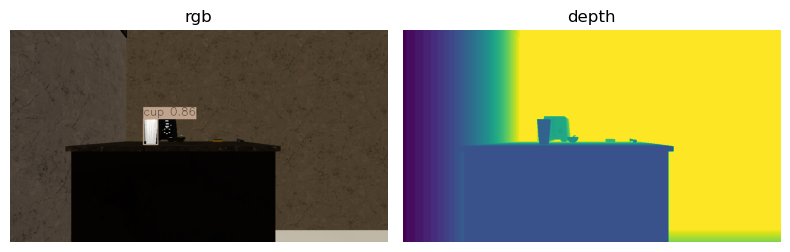

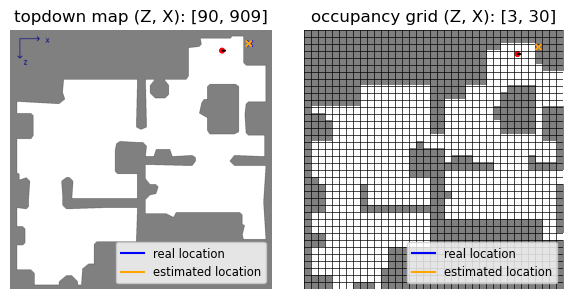

Number of actions: 2
Travelled distance: 0.30 m
Computed localization error: 0.035 m


Simulation 1/200

Target object <cup> found after 107 actions!
Found location: [    -5.9472     0.16774      5.4301]
Real location: [-0.8267626166343689, 0.9443606212735176, 0.48148101568222046]


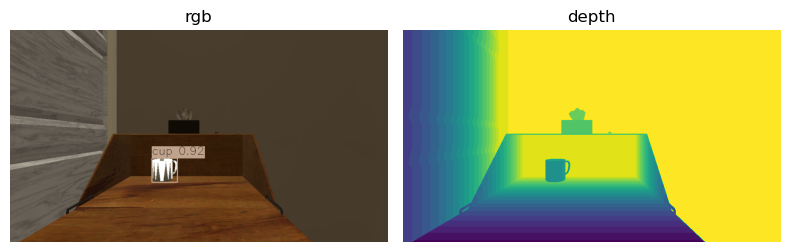

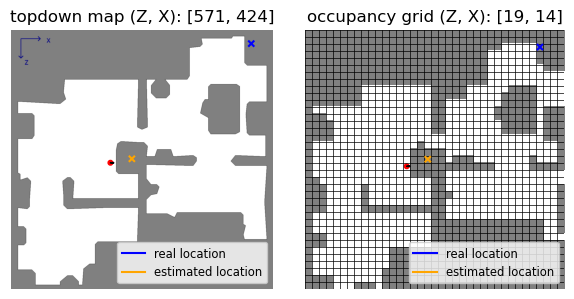

Number of actions: 107
Travelled distance: 21.73 m
Computed localization error: 7.121 m


Simulation 2/200

Target object <cup> found after 76 actions!
Found location: [    -5.9472     0.16774      5.4301]
Real location: [-0.8267626166343689, 0.9443606212735176, 0.48148101568222046]


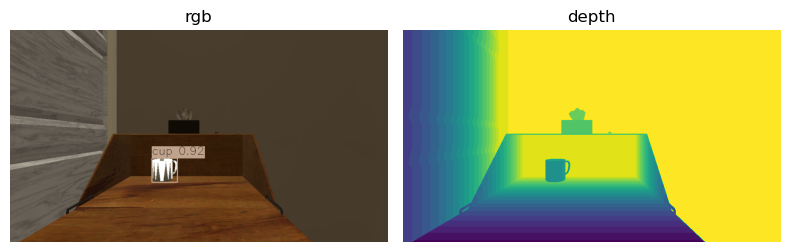

KeyboardInterrupt: 

In [ ]:
for index, (GRID_POSITION, AGENT_YAW) in enumerate(zip(starting_grid_positions, starting_orientations)):

    # Initialize an agent
    agent = sim.initialize_agent(sim_settings["default_agent"])

    # Sample a random position (within the possible ones)
    grid_position = GRID_POSITION
    idx = grid_free_cells.index(grid_position)
    world_position = world_free_coords[idx]
    map_position = map_free_cells[idx]

    # Sample a random yaw rotation
    agent_yaw = AGENT_YAW
    agent_quart = myutils.yaw_to_quaternion(agent_yaw)

    # Set agent state
    agent_state = habitat_sim.AgentState()
    agent_state.position = world_position
    agent_state.rotation = agent_quart
    agent.set_state(agent_state)

    # Compute agent radius in both maps
    min_bounds, max_bounds = sim.pathfinder.get_bounds()
    x_dim = max_bounds[0] - min_bounds[0]
    topdown_radius = (AGENT_RADIUS / x_dim * topdown_resolution[0])
    grid_radius = (AGENT_RADIUS / x_dim * grid_resolution[0])

    # Get initial agent position tuple and radius tuple
    agent_radius = (topdown_radius, grid_radius)
    agent_positions = (map_position, grid_position)

    # Get initial observations and maps
    observations = sim.get_sensor_observations(0)
    rgb = observations["color_sensor"]
    depth = observations["depth_sensor"]
    
    # Display the initial simulation state (maps + observations)
    print(f"\n\nSimulation {index}/{len(starting_grid_positions)}")

    # Metrics initialization
    target_found = False
    num_actions = 0
    travelled_distance = 0.0
    location_error = float("inf")

    # Simulation parameters
    num_clusters = simtools.num_cluster_centers(num_free_cells, max_clusters=num_free_cells)
    MAX_ITER = int(num_free_cells * MAX_ITER_COEF)  # Maximum number of actions to perform
    DISPLAY_STEP = MAX_ITER // 10  # Display every 10% of the actions
    ACTIONS = ACTIONS

    # Main simulation loop
    while (num_clusters <= num_free_cells) and (num_actions < MAX_ITER) and (not target_found):
        
        # Cluster map
        cluster_map = simtools.cluster_mapping(grid_free_cells, num_clusters)
        cluster_centers = simtools.get_cluster_centers(cluster_map, num_clusters)
        cluster_centers_copy = cluster_centers.copy() # For displaying logic

        # Go through each cluster center
        while (cluster_centers) and (num_actions < MAX_ITER) and (not target_found):

            # Select closest cluster center
            cluster_center, path = simtools.get_closest_cluster_path(grid_position, cluster_centers, grid_free_cells)
            #print(f"Next cluster: {cluster_center} Path: {path} Distance: {CELL_SIDE * len(path)} m")

            # Move along the path 
            while (path) and (num_actions < MAX_ITER) and (not target_found):
                
                # Compute actions to move to next path cell
                action_list = simtools.compute_relative_actions(grid_position, agent_yaw, path[0], ACTIONS)

                # Go through each action in the action list
                for action in action_list:
                    # Perform action
                    grid_position, agent_yaw = simtools.perform_action(action, grid_position, agent_yaw)
                    idx = grid_free_cells.index(grid_position)
                    map_position, world_position = map_free_cells[idx], world_free_coords[idx]
                    agent_positions = (map_position, grid_position)
                    agent_quart = myutils.yaw_to_quaternion(agent_yaw)

                    # Update metrics
                    num_actions += 1
                    travelled_distance += simtools.compute_travelled_distance(agent_state.position, world_position)

                    # Update agent state
                    agent_state.position = world_position
                    agent_state.rotation = agent_quart
                    agent.set_state(agent_state)

                    # Get observations
                    obs = sim.get_sensor_observations(0)
                    rgb, depth = obs["color_sensor"], obs["depth_sensor"]

                    # YOLO Prediction
                    results = yolo_model.predict(source=rgb[:,:,:3], device='cuda:0', conf=0.30, iou=0.40, verbose=False, max_det=10)
                    detections = simtools.parse_yolo_detections(results)
                    simtools.merge_rgb_yolo_outputs(rgb, detections)
                    target_found, target_bbox = simtools.was_target_found(TARGET_OBJECT_ID, detections, CONFIDENCE_THRESHOLD)

                    # Check if target was found
                    if target_found: break

                # Remove the path cell from the path
                path.pop(0)

            # Check if the target was found
            if target_found: break

            # Rotate times to get the full 360 degrees view
            for i in range(3):
                # Perform the action
                grid_position, agent_yaw = simtools.perform_action('turn_right', grid_position, agent_yaw)
                agent_quart = myutils.yaw_to_quaternion(agent_yaw)
                agent_state.rotation = agent_quart
                agent.set_state(agent_state)

                # Update metrics
                num_actions += 1

                # Get observations
                obs = sim.get_sensor_observations(0)
                rgb, depth = obs["color_sensor"], obs["depth_sensor"]

                # YOLO Prediction
                results = yolo_model.predict(source=rgb[:,:,:3], device='cuda:0', conf=0.30, iou=0.40, verbose=False, max_det=10)
                detections = simtools.parse_yolo_detections(results)
                simtools.merge_rgb_yolo_outputs(rgb, detections)
                target_found, target_bbox = simtools.was_target_found(TARGET_OBJECT_ID, detections, CONFIDENCE_THRESHOLD)
                
                # If the target object is found, break
                if target_found: break 

            # Remove the grid cluster center from the list
            cluster_centers.remove(cluster_center)

        # Double the number of clusters
        num_clusters *= 2

    # Target found or not
    if target_found:
        # Real world position 
        center_x, center_y = simtools.get_box_center(target_bbox)
        depth_value = depth[center_y, center_x]
        target_object_position = simtools.compute_real_world_position_from_pixel(agent_state.position, agent_state.rotation, depth_value, center_x, center_y, intrinsics)

        # location_error to the target location
        location_error = simtools.compute_location_error(target_object_position, REAL_TARGET_LOCATION)

        # Convert to 2D coordinates
        target_map_position, target_grid_position = simtools.get_2d_coords(target_object_position, topdown_resolution, grid_resolution, sim.pathfinder)
        target_real_map_position, target_real_grid_position = simtools.get_2d_coords(REAL_TARGET_LOCATION, topdown_resolution, grid_resolution, sim.pathfinder)
        target_2d_coords = (target_map_position, target_grid_position)
        target_real_2d_coords = (target_real_map_position, target_real_grid_position)
        target_coords = (target_real_2d_coords, target_2d_coords)

        # Check if location is valid
        if location_error > LOCATION_ERROR_THRESHOLD:
            print(f"\nTarget object <{TARGET_OBJECT}> found after {num_actions} actions, but location error {location_error:.3f} m exceeds threshold {LOCATION_ERROR_THRESHOLD} m. FAILURE!")
            target_found = False
            location_error = float("inf")
        else:
            print(f"\nTarget object <{TARGET_OBJECT}> found after {num_actions} actions!")

        print(f"Found location: {target_object_position}")
        print(f"Real location: {REAL_TARGET_LOCATION}")
        #simtools.display_sim_observations(rgb, depth)
        #simtools.display_topdown_maps_with_target(topdown_map, grid_map, agent_positions, agent_radius, agent_yaw, target_coords)
    else:
        print(f"\nTarget object <{TARGET_OBJECT}> not found after {MAX_ITER} actions!")
        print(f"Real location: {REAL_TARGET_LOCATION}")

    # Display simulation metrics
    print(f"Number of actions: {num_actions}")
    print(f"Travelled distance: {travelled_distance:.2f} m")
    print(f"Computed localization error: {location_error:.3f} m")

    # Append metrics to epochs
    num_actions_epochs.append(num_actions)
    travelled_distance_epochs.append(travelled_distance)
    success_epochs.append(target_found)
    location_error_epochs.append(location_error)

In [ ]:
import numpy as np

# Pre-process
num_actions_epochs = np.array(num_actions_epochs)
travelled_distance_epochs = np.array(travelled_distance_epochs)
success_epochs = np.array(success_epochs)
location_error_epochs = np.array(location_error_epochs)

# Counting
num_total_epochs = len(num_actions_epochs)
num_success_epochs = np.sum(success_epochs)

# Metrics on all runs
total_avg_num_actions = np.sum(num_actions_epochs) / num_total_epochs
total_avg_tavelled_distance = np.sum(travelled_distance_epochs) / num_total_epochs
success_rate = num_success_epochs / num_total_epochs * 100

# Metrics on successful runs
success_avg_travelled_distance = np.sum(travelled_distance_epochs[success_epochs]) / num_success_epochs
success_avg_num_actions = np.sum(num_actions_epochs[success_epochs]) / num_success_epochs
success_avg_location_error = np.sum(location_error_epochs[success_epochs]) / num_success_epochs

#Print final metrics
print("\n\nMETRICS:\n")
print(f"Total number of epochs: {num_total_epochs}")
print(f"Number of successful epochs: {num_success_epochs}")
print(f"Success rate: {success_rate:.2f}%")
print(f"Average number of actions (epochs): {total_avg_num_actions:.2f}")
print(f"Average travelled distance (epochs): {total_avg_tavelled_distance:.2f} m")
print(f"Average success rate (epochs): {success_rate:.2f}%")
print(f"\nAverage number of actions (successful epochs): {success_avg_num_actions:.2f}")
print(f"Average travelled distance (successful epochs): {success_avg_travelled_distance:.2f} m")
print(f"Average location error (successful epochs): {success_avg_location_error:.3f} m")

# Number of actions max, min and std
print(f"\nMax number of actions (epochs): {np.max(num_actions_epochs)}")
print(f"Min number of actions (epochs): {np.min(num_actions_epochs)}")
print(f"Std number of actions (epochs): {np.std(num_actions_epochs)}")    

In [ ]:
metrics_file = 'results/metrics.json'

# Load existing metrics if the file exists, otherwise start with an empty list
if os.path.exists(metrics_file):
    with open(metrics_file, 'r') as f:
        existing_metrics = json.load(f)
else:
    existing_metrics = []

# New metrics entry (convert numpy types to native Python types)
def to_python_type(val):
    if hasattr(val, "item"):
        return val.item()
    return val

new_metrics = {
    "simulation_index": to_python_type(INDEX),
    "scene": SCENE,
    "target_object": TARGET_OBJECT,
    "search_method": METHOD,
    "confidence_threshold": to_python_type(CONFIDENCE_THRESHOLD),
    "max_iter_coefficient": to_python_type(MAX_ITER_COEF),
    "location_error_threshold": to_python_type(LOCATION_ERROR_THRESHOLD),
    "num_total_epochs": to_python_type(num_total_epochs),
    "num_success_epochs": to_python_type(num_success_epochs),
    "success_rate": to_python_type(success_rate),
    "total_avg_num_actions": to_python_type(total_avg_num_actions),
    "total_avg_tavelled_distance": to_python_type(total_avg_tavelled_distance),
    "success_avg_num_actions": to_python_type(success_avg_num_actions),
    "success_avg_travelled_distance": to_python_type(success_avg_travelled_distance),
    "success_avg_location_error": to_python_type(success_avg_location_error),
}

# Check for duplicate (by simulation_index and search_method)
duplicate_exists = any(
    entry["simulation_index"] == new_metrics["simulation_index"] and
    entry["search_method"] == new_metrics["search_method"] and
    entry["confidence_threshold"] == new_metrics["confidence_threshold"] 
    for entry in existing_metrics
)

if not duplicate_exists:
    existing_metrics.append(new_metrics)
else:
    print(f"Metrics for simulation_index {new_metrics['simulation_index']} and search_method '{new_metrics['search_method']}' already exist. Skipping append.")

# Save updated metrics list
with open(metrics_file, 'w') as f:
    json.dump(existing_metrics, f, indent=4)

print(f"\nMetrics saved to {metrics_file}")


In [ ]:
sim.close()  # Close the simulator